# Statistical Mechanics of Fluids

:::{admonition} **What you will learn**

- The classical fluid Hamiltonian factorizes into ideal-gas (kinetic) and configurational (interaction) parts; the **configurational partition function** $Q$ is what makes liquids hard.
- The **radial distribution function** $g(r)$ is the central object that connects microscopic structure to thermodynamics.
- $g(r)$ has two complementary readings: a *structural* one (where the neighbor shells sit) and a *thermodynamic* one (the **potential of mean force** $w(r) = -k_B T \ln g(r)$).
- Energy, pressure, and the **second virial coefficient** $B_2(T)$ all follow from $g(r)$ — for any pair potential.

:::

## From phase space to the configurational integral

A classical fluid of $N$ particles in volume $V$ at temperature $T$ has a Hamiltonian that splits cleanly:

$$
H(\mathbf{r}^N, \mathbf{p}^N) \;=\; \sum_{i=1}^N \frac{\mathbf{p}_i^{\,2}}{2m} \;+\; U(\mathbf{r}^N).
$$

Because the kinetic and configurational pieces add, the canonical partition function factorizes:

$$
Z(\beta, V, N) \;=\; \frac{1}{N!\, \lambda^{3N}} \underbrace{\int e^{-\beta U(\mathbf{r}^N)}\, d\mathbf{r}^N}_{\equiv\, Q(\beta, V, N)},
\qquad \lambda \;=\; \frac{h}{\sqrt{2\pi m k_B T}}.
$$

The kinetic prefactor is exactly the ideal gas. **Everything that makes a liquid a liquid lives in $Q$**, the configurational integral. Computing $Q$ analytically is impossible for any realistic $U$ — we need either approximations (mean-field theories, virial expansions) or simulations.

The pressure is

$$
p \;=\; -\frac{\partial F}{\partial V} \;=\; k_B T \, \frac{\partial \ln Q}{\partial V}.
$$

For a *stable* equilibrium fluid the volume dependence of $Q$ gives $p > 0$, but a fluid stretched into the metastable region can sustain $p < 0$ transiently before cavitating — the inequality is a stability statement, not an absolute one.


## Reduced distribution functions

We rarely need the full $N$-body probability $P(\mathbf{r}^N) = e^{-\beta U}/Q$. Most thermodynamic quantities depend only on **low-order marginals**. Define the $n$-particle density

$$
\rho^{(n)}(\mathbf{r}_1, \dots, \mathbf{r}_n) \;=\; \frac{N!}{(N-n)!} \int d\mathbf{r}_{n+1} \cdots d\mathbf{r}_N\, P(\mathbf{r}^N).
$$

The combinatorial prefactor counts the $N!/(N-n)!$ ways to label particles at positions $\mathbf{r}_1, \dots, \mathbf{r}_n$. For a *homogeneous, isotropic* fluid the one-body density is constant, $\rho^{(1)} = N/V \equiv \rho$. The two-body density depends only on the separation $r = |\mathbf{r}_1 - \mathbf{r}_2|$, and it defines the **radial distribution function** $g(r)$ via

$$
\boxed{\;\rho^{(2)}(\mathbf{r}_1, \mathbf{r}_2) \;=\; \rho^{2}\, g(r)\;}
$$

Read this as: $\rho\, g(r)$ is the *local* density at distance $r$ from a tagged particle. For an ideal gas $g(r) = 1$ everywhere; for a real fluid $g(r)$ is small at small $r$ (excluded volume), oscillates around $1$ at intermediate $r$ (coordination shells), and approaches $1$ at large $r$ (uncorrelated).


## Reading $g(r)$: shells, packing, structure

Three features of a liquid's $g(r)$ encode different physics:

1. **The first peak** at $r \approx \sigma$ is the contact distance set by hard-core repulsion. Its height grows with density as the first solvation shell becomes more occupied.
2. **The first minimum** sets the boundary of the first coordination shell; integrating up to it gives the **coordination number**

   $$ n_c \;=\; \rho \int_0^{r_{\min}} g(r)\, 4\pi r^2\, dr. $$

3. **Damped oscillations** beyond the first peak reflect packing — like ripples around each particle. They die out at $r$ much larger than the correlation length.

The figures below contrast a dilute gas, dense gas, liquid, and crystal.


![](./figs/gr1_1.png)
![](./figs/gr2_2.png)
![](./figs/gr3_3.png)
![](./figs/gr4_4.png)


## Hands-on: $g(r)$ from a 2D Lennard-Jones simulation

To make this concrete, run a quick Monte-Carlo simulation of a 2D Lennard-Jones fluid and measure $g(r)$ directly. The 2D normalization uses **shell area** $2\pi r\, dr$ instead of $4\pi r^2 dr$:

$$
g(r) \;=\; \frac{2 \,\langle n_{\text{pair}}(r) \rangle}{N \rho \cdot 2\pi r\, dr},
$$

where $\langle n_{\text{pair}}(r) \rangle$ is the average histogram count of pair separations falling in the annulus $[r, r+dr]$ (each unordered pair counted once — hence the factor of 2).


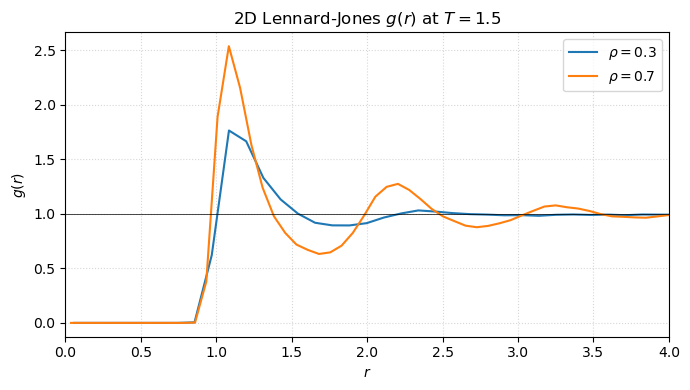

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit

rng = np.random.default_rng(0)


@njit
def lj_mc_2d_with_gr(N, L, T, n_sweeps, max_disp, n_bins, r_max, seed):
    np.random.seed(seed)
    side = int(np.sqrt(N))
    pos = np.empty((N, 2))
    spacing = L / side
    for ix in range(side):
        for iy in range(side):
            k = ix * side + iy
            pos[k, 0] = (ix + 0.5) * spacing
            pos[k, 1] = (iy + 0.5) * spacing

    rcut2 = r_max * r_max
    hist = np.zeros(n_bins, dtype=np.int64)
    beta = 1.0 / T
    n_samples = 0

    for sweep in range(n_sweeps):
        for _ in range(N):
            i = np.random.randint(N)
            old_x, old_y = pos[i, 0], pos[i, 1]

            # energy of particle i at old position
            old_e = 0.0
            for j in range(N):
                if j == i:
                    continue
                dx = old_x - pos[j, 0]
                dy = old_y - pos[j, 1]
                dx -= L * round(dx / L)
                dy -= L * round(dy / L)
                r2 = dx * dx + dy * dy
                if r2 < rcut2 and r2 > 1e-12:
                    inv2 = 1.0 / r2
                    inv6 = inv2 * inv2 * inv2
                    old_e += 4.0 * (inv6 * inv6 - inv6)

            # propose move
            new_x = (old_x + (np.random.random() - 0.5) * 2.0 * max_disp) % L
            new_y = (old_y + (np.random.random() - 0.5) * 2.0 * max_disp) % L

            # energy at new position
            new_e = 0.0
            for j in range(N):
                if j == i:
                    continue
                dx = new_x - pos[j, 0]
                dy = new_y - pos[j, 1]
                dx -= L * round(dx / L)
                dy -= L * round(dy / L)
                r2 = dx * dx + dy * dy
                if r2 < rcut2 and r2 > 1e-12:
                    inv2 = 1.0 / r2
                    inv6 = inv2 * inv2 * inv2
                    new_e += 4.0 * (inv6 * inv6 - inv6)

            if np.random.random() < np.exp(-beta * (new_e - old_e)):
                pos[i, 0] = new_x
                pos[i, 1] = new_y

        # sample pair histogram after burn-in
        if sweep >= n_sweeps // 3:
            for i in range(N - 1):
                for j in range(i + 1, N):
                    dx = pos[i, 0] - pos[j, 0]
                    dy = pos[i, 1] - pos[j, 1]
                    dx -= L * round(dx / L)
                    dy -= L * round(dy / L)
                    r = np.sqrt(dx * dx + dy * dy)
                    if r < r_max:
                        b = int(r / r_max * n_bins)
                        if b < n_bins:
                            hist[b] += 1
            n_samples += 1

    return pos, hist, n_samples


def gr_from_hist(hist, n_samples, N, rho, r_max):
    n_bins = len(hist)
    edges = np.linspace(0, r_max, n_bins + 1)
    r = 0.5 * (edges[:-1] + edges[1:])
    dr = edges[1] - edges[0]
    shell = 2.0 * np.pi * r * dr                      # 2D shell area
    return r, 2.0 * hist / (n_samples * N * rho * shell)


# Run two densities at the same temperature
N, T, n_sweeps, max_disp, n_bins = 100, 1.5, 4000, 0.15, 80
results = {}
for rho in [0.3, 0.7]:
    L = np.sqrt(N / rho)
    _, hist, ns = lj_mc_2d_with_gr(N, L, T, n_sweeps, max_disp, n_bins, L / 2, 0)
    r, g = gr_from_hist(hist, ns, N, rho, L / 2)
    results[rho] = (r, g)

fig, ax = plt.subplots(figsize=(7, 4))
for rho, (r, g) in results.items():
    ax.plot(r, g, lw=1.5, label=fr'$\rho = {rho}$')
ax.axhline(1, color='k', lw=0.5)
ax.set(xlabel='$r$', ylabel='$g(r)$', xlim=(0, 4),
       title=f'2D Lennard-Jones $g(r)$ at $T={T}$')
ax.legend()
ax.grid(True, ls=':', alpha=0.5)
fig.tight_layout()

The dilute curve has only a small first peak; the dense curve develops the characteristic damped oscillations of a liquid. Both approach 1 at large $r$ — particles far away are uncorrelated.

## The reversible work theorem: $g(r)$ as a free energy

There is a striking second reading of $g(r)$. Define the **potential of mean force** $w(r)$ by

$$
g(r) \;=\; e^{-\beta w(r)}, \qquad w(r) \;=\; -k_B T \ln g(r).
$$

$w(r)$ is the *reversible work* required to bring two tagged particles from infinity to separation $r$ in the presence of all the others — fully equilibrated. Where $g(r)$ peaks, $w(r)$ has a *minimum*: a coordination-shell separation is favored. Where $g(r)$ dips below 1 (the trough between shells), $w(r)$ has a *barrier*.

This is more than a relabeling. The mean force at fixed separation is

$$
\langle \mathbf{F}_{12}\rangle_r \;=\; -\nabla w(r) \;=\; k_B T\, \nabla \ln g(r),
$$

so $w(r)$ governs the slow, large-scale motion of pairs of particles in a liquid — exactly the picture you need for diffusion, association, and reaction kinetics in solution.


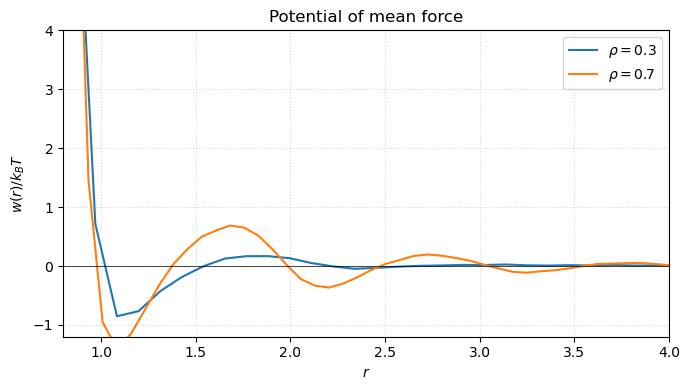

In [2]:
# w(r) = -k_B T log g(r) from the simulated RDF
fig, ax = plt.subplots(figsize=(7, 4))
for rho, (r, g) in results.items():
    g_safe = np.where(g > 1e-3, g, 1e-3)
    w = -T * np.log(g_safe)
    ax.plot(r, w, lw=1.5, label=fr'$\rho = {rho}$')
ax.axhline(0, color='k', lw=0.5)
ax.set(xlabel='$r$', ylabel='$w(r) / k_B T$', xlim=(0.8, 4), ylim=(-1.2, 4),
       title='Potential of mean force')
ax.legend()
ax.grid(True, ls=':', alpha=0.5)
fig.tight_layout()

At low density $w(r)$ is essentially the bare LJ potential — $g(r) \to e^{-\beta u(r)}$. At higher density correlations dress $w(r)$: the well shifts, secondary minima appear, and the long-range tail picks up oscillatory structure. In water, for example, $w(r)$ between two methane-like solutes carries a *desolvation barrier* that is entirely a many-body effect.

## Thermodynamics from $g(r)$

For pairwise interactions, $g(r)$ determines the most important fluid thermodynamic quantities. In 3D:

**Energy per particle**

$$
\frac{\langle E\rangle}{N} \;=\; \frac{3}{2} k_B T \;+\; \frac{\rho}{2} \int_0^\infty g(r)\, u(r)\, 4\pi r^2\, dr.
$$

Each particle has $\rho \cdot g(r) \cdot 4\pi r^2 dr$ neighbors at separation $r$, each contributing $u(r)$; the factor of $1/2$ avoids double counting.

**Pressure (virial equation)**

$$
\frac{p}{\rho k_B T} \;=\; 1 \;-\; \frac{\rho}{6 k_B T} \int_0^\infty r u'(r)\, g(r)\, 4\pi r^2\, dr.
$$

The first term is the ideal gas; the integral is the **virial correction**. In an MD simulation $g(r)$ is what the histogram counts, and these two formulas turn it into thermodynamics.

## Low-density limit and the second virial coefficient

In the dilute limit, multi-body correlations are rare and a particle "feels" only its instantaneous partner:

$$
g(r) \;\xrightarrow{\rho \to 0}\; e^{-\beta u(r)}.
$$

Plug this into the pressure equation and Taylor-expand in $\rho$ to obtain the **virial expansion**

$$
\frac{p}{k_B T} \;=\; \rho \;+\; B_2(T)\, \rho^2 \;+\; B_3(T)\, \rho^3 \;+\; \cdots,
$$

where the second virial coefficient is

$$
B_2(T) \;=\; -\frac{1}{2} \int_0^\infty \!\left[ e^{-\beta u(r)} - 1 \right] 4\pi r^2\, dr.
$$

The integrand is the **Mayer $f$-function** $f(r) = e^{-\beta u(r)} - 1$. It captures *deviations from ideality*: $f(r) < 0$ in the repulsive core (excluded volume), $f(r) > 0$ in the attractive well (over-density). 

- At low $T$ attraction wins and $B_2 < 0$ — the gas attracts itself; at high $T$ excluded volume wins and $B_2 > 0$, the gas repels itself. 
- The temperature where $B_2(T) = 0$ is the **Boyle temperature** $T_B$, where the gas behaves *ideally to second order* despite microscopic interactions.


Boyle temperature for LJ: T_B = 3.4083  (literature: ~3.418)


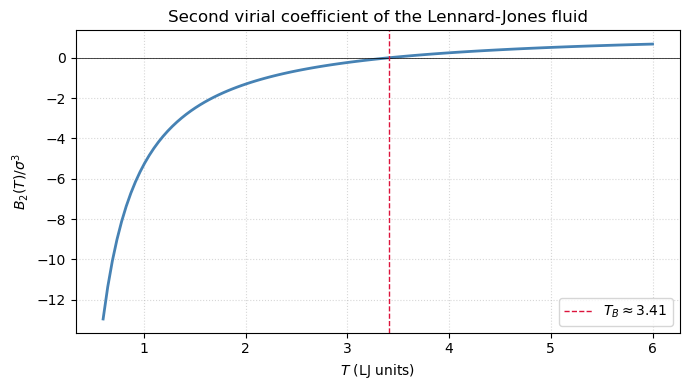

In [3]:
from scipy.integrate import quad
from scipy.optimize import brentq


def b2_lj(T, sigma=1.0, eps=1.0):
    '''B_2(T) for Lennard-Jones in 3D, in units of sigma^3.'''
    def integrand(r):
        u = 4.0 * eps * ((sigma / r) ** 12 - (sigma / r) ** 6)
        return (1.0 - np.exp(-u / T)) * r * r
    val, _ = quad(integrand, 1e-3, 8.0, limit=200)
    return 2.0 * np.pi * val


T_grid = np.linspace(0.6, 6.0, 120)
B2 = np.array([b2_lj(T) for T in T_grid])

T_Boyle = brentq(b2_lj, 2.0, 5.0)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(T_grid, B2, color='steelblue', lw=2)
ax.axhline(0, color='k', lw=0.5)
ax.axvline(T_Boyle, color='crimson', ls='--', lw=1,
           label=fr'$T_B \approx {T_Boyle:.2f}$')
ax.set(xlabel='$T$ (LJ units)', ylabel=r'$B_2(T) / \sigma^3$',
       title='Second virial coefficient of the Lennard-Jones fluid')
ax.legend()
ax.grid(True, ls=':', alpha=0.5)
fig.tight_layout()

print(f'Boyle temperature for LJ: T_B = {T_Boyle:.4f}  (literature: ~3.418)')

## Takeaways

- The whole fluid problem reduces to evaluating the **configurational integral $Q$**, that is what simulation does.
- $g(r)$ is the **two-point** marginal of the configurational distribution, and almost every thermodynamic quantity is a moment of $g(r)$ against some weight: energy weights it by $u(r)$, pressure by $r u'(r)$, virial coefficients by Mayer's $f(r)$.
- $g(r)$ has a *thermodynamic* identity through the reversible-work theorem: $w(r) = -k_B T \ln g(r)$ is the free-energy profile felt by a pair embedded in the fluid.
- The low-density expansion ($g(r) \to e^{-\beta u}$) connects $B_2(T)$ directly to the pair potential and locates the **Boyle temperature** where attractive and repulsive contributions balance.


## Problems

1. **Coordination number.** Run the 2D LJ simulation at $T = 1.5$ and $\rho = 0.7$. Identify the location $r_{\min}$ of the first minimum of $g(r)$ and integrate $\rho \cdot g(r) \cdot 2\pi r\, dr$ from 0 to $r_{\min}$ — the result is the average number of *first-shell neighbors*. Repeat at $\rho = 0.3$ and $\rho = 0.85$ and report how the coordination number changes with density.

2. **$B_2$ for the square-well potential.** For $u(r) = +\infty$ for $r < \sigma$, $-\varepsilon$ for $\sigma \le r < \lambda \sigma$, and $0$ for $r > \lambda \sigma$, compute $B_2(T)$ analytically. Show that the Boyle temperature satisfies $\lambda^3 - 1 = (e^{\varepsilon/k_B T_B} - 1)^{-1}$, i.e. $k_B T_B = \varepsilon / \ln(1 + 1/(\lambda^3 - 1))$, and plot $T_B(\lambda)$.

3. **Pressure from $g(r)$.** From the simulated $g(r)$ at $\rho = 0.7$, $T = 1.5$ compute the configurational contribution to the 2D pressure (replace $4\pi r^2$ with $2\pi r$ and $\frac{\rho}{6 k_B T}$ with $\frac{\rho}{4 k_B T}$ in the virial formula — the dimensional factors change). Compare to the ideal-gas value $\rho k_B T$; comment on its sign.

### Reference

J.-P. Hansen and I. R. McDonald, *Theory of Simple Liquids*, 4th ed. (Academic Press, 2013) — chapters 2 (distribution functions) and 3 (perturbation theory). The standard text on everything above.
